<a href="https://colab.research.google.com/github/danielcoria8/Wine_Multiclass_Perceptron_Final_Project/blob/main/Intro_ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Don’t Know Wines? Don’t Wine About It!**
*Creating a Pocket Winery using a Multi-Class Perceptron*

Asya Tarabar, Felicia Zheng, Daniel Coria, Morgan Taylor

In [ ]:
import numpy as np
import sklearn.datasets as skdata
from sklearn.linear_model import Perceptron
import sklearn.metrics as skmetrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
import warnings, time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold


warnings.filterwarnings(action='ignore')
np.random.seed(42)

In [ ]:
# Load the data from github
!git clone https://github.com/danielcoria8/Wine_Multiclass_Perceptron_Final_Project.git
import pandas as pd
df = pd.read_csv("/content/Wine_Multiclass_Perceptron_Final_Project/XWines_Full_100K_wines.csv")
#print(df.head())
#print(df.shape)


fatal: destination path 'Wine_Multiclass_Perceptron_Final_Project' already exists and is not an empty directory.


In [ ]:
# engineering sweetness level from ABV, body and acidity
sweet_grapes = ["muscat", "moscato", "riesling", "gewurztraminer",
                "chenin", "sauternes", "beerenauslese"]

def classify_sweetness(row):
    body = str(row["Body"]).lower()
    acidity = str(row["Acidity"]).lower()
    abv = row["ABV"]

    sweet_score = 0
    dry_score = 0

    if abv < 11.5:
        sweet_score += 2
    elif abv > 13.0:
        dry_score += 2

    if "light" in body:
        sweet_score += 2
    elif "full" in body:
        dry_score += 1

    if "high" in acidity:
        sweet_score += 2
    elif "low" in acidity:
        dry_score += 1

    if sweet_score > dry_score:
        return "sweet"
    elif dry_score > sweet_score:
        return "dry"
    else:
        return "medium"

df["Sweetness"] = df.apply(classify_sweetness, axis=1)


# 7 classes: rose, dry white, medium white, sweet white, dry red, medium red, sweet red
def make_label(row):
    if row["Type"] == "Rosé":
        return "rosé"
    else:
        return f'{row["Sweetness"]} {row["Type"].lower()}'

df["FinalLabel"] = df.apply(make_label, axis=1)

print(df["FinalLabel"].value_counts())



FinalLabel
dry red         33973
sweet white     16443
sweet red       14714
dry white        8191
medium red       7475
medium white     4562
rosé             4401
Name: count, dtype: int64


In [ ]:
# Vectorizing using skmetrics
feature_columns = [
    "WineName",
    "Grapes",
    "ABV",
    "Body",
    "Acidity",
    "Country",
    "RegionName"
]

# Sampling so we don't run out of RAM
df_model = df.sample(n=30000, random_state=42)

X_raw = df_model[feature_columns]
y_text = df_model["FinalLabel"]

# Just split train and test, no val needed
X_train_raw, X_test_raw, y_train_text, y_test_text = train_test_split(
    X_raw,
    y_text,
    test_size=0.15,  # same proportion as before
    random_state=42,
    stratify=y_text
)

# Making labels!
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

# Vectorize final step, using fewer features because we keep running out of ram
vectorizer = ColumnTransformer(
    transformers=[
        ("wine_name", TfidfVectorizer(ngram_range=(1, 2), max_features=1000), "WineName"),
        ("grapes", TfidfVectorizer(ngram_range=(1, 2), max_features=500), "Grapes"),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Body", "Acidity", "Country", "RegionName"]),
        ("numeric", StandardScaler(), ["ABV"])
    ]
)

In [ ]:

class MulticlassPerceptron:

    def __init__(self, learning_rate=1.0, shuffle=True, random_state=42):
        self.__weights = None
        self.__n_classes = None
        self.learning_rate = learning_rate
        self.shuffle = shuffle
        self.random_state = random_state

    def __update(self, x, y, y_hat):
        self.__weights[:, y] += self.learning_rate * x[:, 0]
        self.__weights[:, y_hat] -= self.learning_rate * x[:, 0]


    def fit(self, x, y, max_iter=100):
        y = np.ravel(y)
        n_features, n_samples = x.shape

        self.__n_classes = len(np.unique(y))

        # Adding bias coord
        x = np.vstack((np.ones((1, n_samples)), x))

        self.__weights = np.zeros((n_features + 1, self.__n_classes))

        rng = np.random.default_rng(self.random_state)

        for epoch in range(max_iter):
            n_updates = 0

            if self.shuffle:
                indices = rng.permutation(n_samples)
            else:
                indices = np.arange(n_samples)

            for i in indices:
                xi = x[:, i].reshape(-1, 1)
                yi = int(y[i])

                scores = np.dot(self.__weights.T, xi)
                y_hat = np.argmax(scores)

                if y_hat != yi:
                    self.__update(xi, yi, y_hat)
                    n_updates += 1

            if n_updates == 0:
                break


    def predict(self, x):

        n_features, n_samples = x.shape

        # Add artificial bias coordinate
        x = np.vstack((np.ones((1, n_samples)), x))

        scores = np.dot(self.__weights.T, x)
        return np.argmax(scores, axis=0)

    def score(self, x, y):

        y = np.ravel(y)
        y_hat = self.predict(x)

        return np.mean(y_hat == y)


In [ ]:
MAX_ITERS = [50, 100, 150, 200, 300]

# testing max iterations for best fit model (reduce under/overfit)

def cross_validate(X, y, n_splits=5, random_state=42):
    print('*** PERFORMING STRATIFIED K-FOLD CROSS VALIDATION ***')
    k_fold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    mean_acc_per_iter = {}
    best_iter = None
    best_mean_acc = float('-inf')
    fold_test_accuracies_best = None

    for num_iters in MAX_ITERS:

        fold_test_accuracies = []


        for fold_idx, (train_idx, test_idx) in enumerate(k_fold.split(X, y)):

            X_train_fold = X[train_idx].T
            y_train_fold = y[train_idx]
            X_test_fold  = X[test_idx].T
            y_test_fold  = y[test_idx]

            model = MulticlassPerceptron(learning_rate=1.0, shuffle=True, random_state=random_state)
            model.fit(X_train_fold, y_train_fold, max_iter=num_iters)

            fold_acc = model.score(X_test_fold, y_test_fold)
            fold_test_accuracies.append(fold_acc)

            print(f'[max_iter={num_iters}] [FOLD {fold_idx+1}/{n_splits}] | test accuracy={fold_acc:.4f}')

        mean_acc = np.mean(fold_test_accuracies)
        mean_acc_per_iter[num_iters] = mean_acc

        print(f'[max_iter={num_iters}] Mean accuracy across folds: {mean_acc:.4f}\n')

        if mean_acc > best_mean_acc:
            best_mean_acc = mean_acc
            best_iter = num_iters
            fold_test_accuracies_best = fold_test_accuracies

    print('*** CROSS VALIDATION RESULTS ***')
    print('Mean accuracy per max_iter:', mean_acc_per_iter)
    print('Best max_iter:', best_iter)
    print(f'Best mean accuracy: {best_mean_acc:.4f}')
    print(f'Mean ± std (best): {np.mean(fold_test_accuracies_best):.4f} ± {np.std(fold_test_accuracies_best):.4f}\n')

    return mean_acc_per_iter, best_iter, fold_test_accuracies_best

*** PERFORMING STRATIFIED K-FOLD CROSS VALIDATION ***
[max_iter=50] [FOLD 1/5] | test accuracy=0.9525
[max_iter=50] [FOLD 2/5] | test accuracy=0.9265
[max_iter=50] [FOLD 3/5] | test accuracy=0.9524
[max_iter=50] [FOLD 4/5] | test accuracy=0.9545
[max_iter=50] [FOLD 5/5] | test accuracy=0.9518
[max_iter=50] Mean accuracy across folds: 0.9475

[max_iter=100] [FOLD 1/5] | test accuracy=0.9571
[max_iter=100] [FOLD 2/5] | test accuracy=0.9529
[max_iter=100] [FOLD 3/5] | test accuracy=0.9484
[max_iter=100] [FOLD 4/5] | test accuracy=0.9537
[max_iter=100] [FOLD 5/5] | test accuracy=0.9527
[max_iter=100] Mean accuracy across folds: 0.9530

[max_iter=150] [FOLD 1/5] | test accuracy=0.9535
[max_iter=150] [FOLD 2/5] | test accuracy=0.9508
[max_iter=150] [FOLD 3/5] | test accuracy=0.9576
[max_iter=150] [FOLD 4/5] | test accuracy=0.9508
[max_iter=150] [FOLD 5/5] | test accuracy=0.9512
[max_iter=150] Mean accuracy across folds: 0.9528

[max_iter=200] [FOLD 1/5] | test accuracy=0.9529
[max_iter=200] 

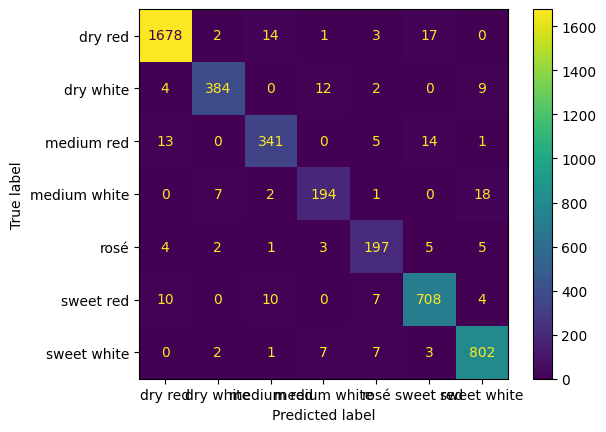

In [ ]:

X_train = vectorizer.fit_transform(X_train_raw).toarray()
X_test = vectorizer.transform(X_test_raw).toarray()

# WARNING: CROSS VALIDATION TAKES AROUND 30 MINUTES
# cross validate to find best max_iter
mean_acc_per_iter, best_iter, fold_accs = cross_validate(
    X_train, y_train, n_splits=5, random_state=42)

# Retrain final model using best_iter
final_model = MulticlassPerceptron(learning_rate=1.0, shuffle=True, random_state=42)
final_model.fit(X_train.T, y_train, max_iter=best_iter)

print('*** PREDICTED LABEL DISTRIBUTION ***')
# Checking distribution to make sure one class isn't dominating
print(df["FinalLabel"].value_counts())

print('\n*** FINAL MODEL RESULTS ***')
print("\nTest accuracy:", final_model.score(X_test.T, y_test))

# confusion matrix
y_pred = final_model.predict(X_test.T)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

